# 🏡 California Housing — Exploratory Data Analysis

This notebook performs a clean, professional EDA on the California Housing dataset.

**Goals:**
- Understand the dataset structure
- Explore distributions and correlations
- Identify patterns useful for modeling
- Prepare insights for the Random Forest model

This notebook is part of a full ML workflow project.

<a href="https://colab.research.google.com/github/Robbie669/data-science-portfolio/blob/main/projects/california-housing/01_eda.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Run in Colab"/>
</a>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

sns.set(style="whitegrid", context="notebook")

## 1. Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Basic Info & Summary Statistics

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 3. Distribution of Target Variable
Understanding the distribution of `MedHouseVal` helps guide model selection and evaluation.

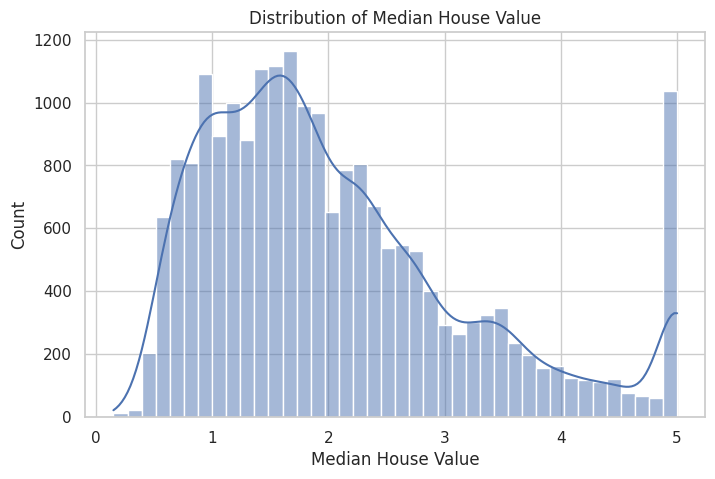

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], kde=True, bins=40)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.show()

## 4. Feature Distributions
Quick overview of each feature's distribution.

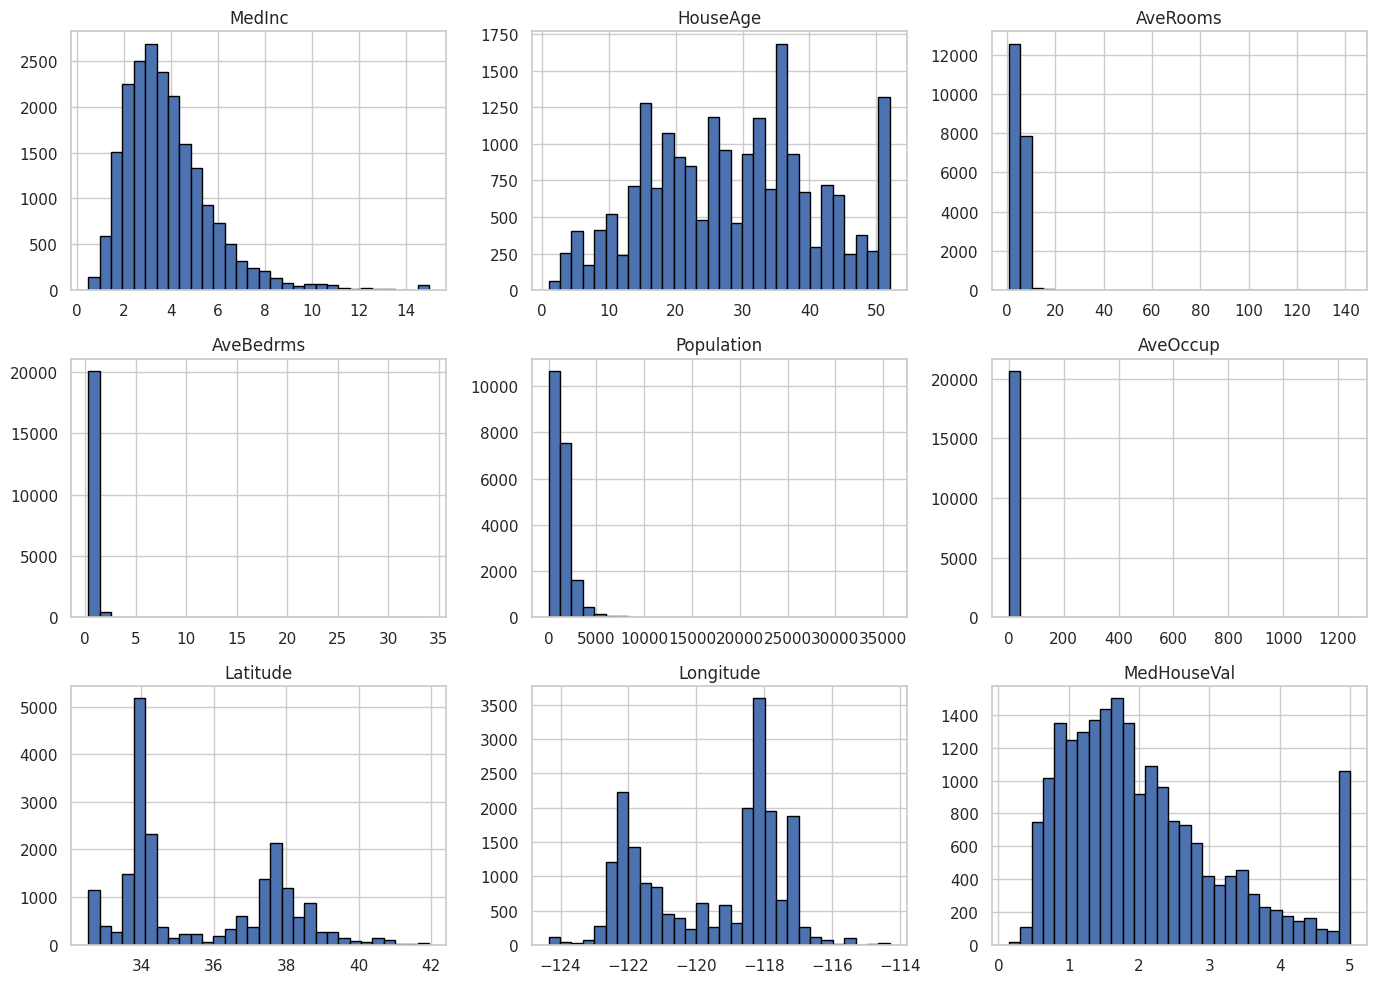

In [6]:
df.hist(figsize=(14,10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap
This helps identify relationships between features and the target.

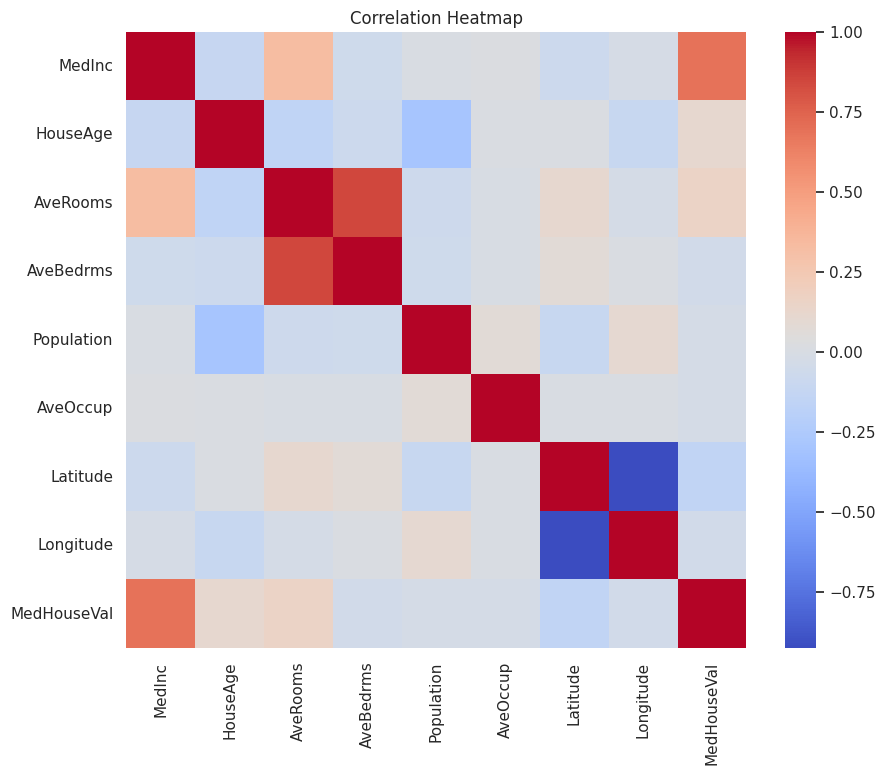

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

## 6. Scatterplots for Key Relationships
A few targeted visualizations to understand important drivers of house value.

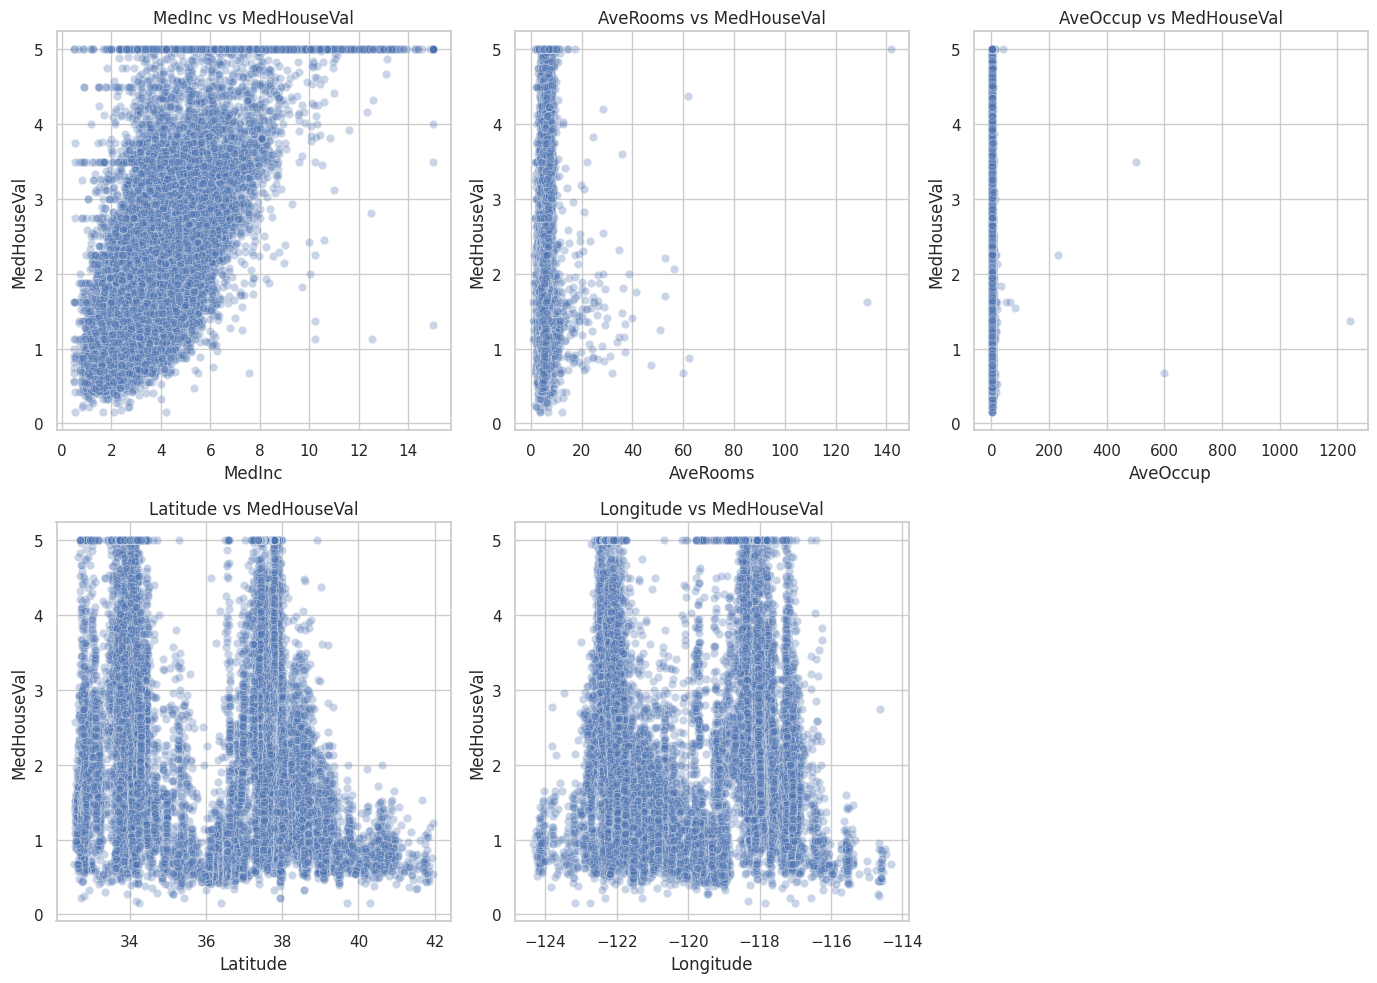

In [8]:
features_to_plot = ["MedInc", "AveRooms", "AveOccup", "Latitude", "Longitude"]

plt.figure(figsize=(14,10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feature], y=df['MedHouseVal'], alpha=0.3)
    plt.title(f"{feature} vs MedHouseVal")

plt.tight_layout()
plt.show()

## 7. Geographic Patterns
Latitude and longitude often reveal strong spatial patterns in housing data.

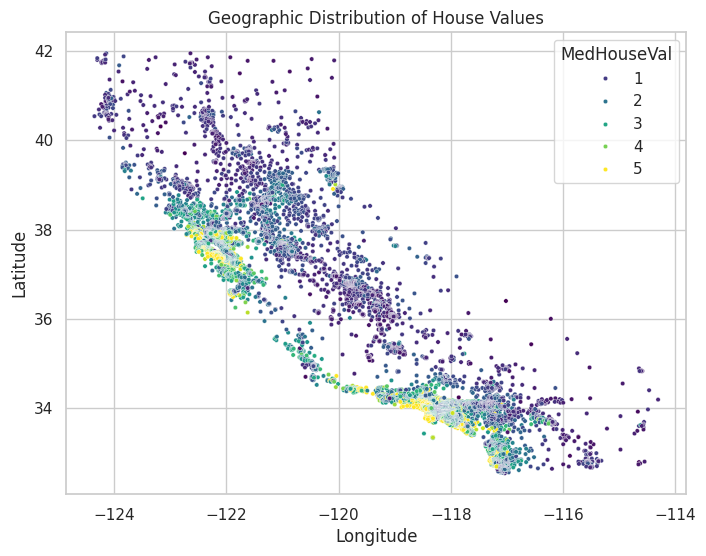

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Longitude'], y=df['Latitude'], hue=df['MedHouseVal'], palette='viridis', s=10)
plt.title("Geographic Distribution of House Values")
plt.show()

## 8. Key Insights

- **Median Income** is the strongest predictor of house value.
- **Latitude/Longitude** show clear geographic clustering.
- **Rooms and population density** have moderate relationships.
- Distributions are skewed, but Random Forest handles this well.

This EDA informs the modeling decisions in the next notebook.